# GCAM Annual Meeting 2023 - `stitches` training

The purpose of this tutorial is to demonstrate how `stitches` can be used as an
emulator. While `stitches` can  emulate a number of CMIP6 models, this example
 will focus on emulating CanESM5 SSP245 results.

This tutorial also assumes that the user has either seen a talk on `stitches` or
read the paper published in _Earth System Dyanmics_ (Tebaldi et al 2022). This
tutorial is aimed at highlighting the flexibility of functions in `stitches`.

A simpler quickstart notebook comes in every stitches download and includes
installation instructions:

https://github.com/JGCRI/stitches/blob/main/notebooks/stitches-quickstart.ipynb

A more detailed and involved version of this training is available as well:

https://github.com/JGCRI/stitches/blob/dev/notebooks/stitches_takehome_GCAMAnnualMeeting2023.ipynb

All notebooks assume a familiarity with CMIP-style data.

To use `stitches`, there are a number of decisions users have to make,
perhaps the most important being:

* Which ESM will `stitches` emulate?
* What _archive data_ will be used? These are values of global temperature (in the
following referred to as GSAT, or Tgav, or tas) for experiments/time periods (e.g.,
historical and SSP realizations) that the target data will be matched to. It should
only contain data for the specific ESM that is being emulated.
* What _target data_ will be used? This data frame represents the temperature
pathway the stitched product will follow. The contents of this data frame may
come from computing GSAT from CMIP6 ESM temperature output (as we do in this
tutorial)  according to a standard  SSP scenario,  or it may follow some alternate
pathway that a simple model like Hector or FaIR has produced.

A diagram illustrating the `stitches` process is included for reference:

![stitches workflow](figs/stitches_diagram.jpg)

- `stitches` defaults to $X=9$ year windows.


STITCHES works by matching X-year segments of a target GSAT
trajectory to X-year segments of available GSAT trajectories, computed from the
archived output of an ESM that has been run according to SSP scenarios.

The
choice of X balances the need to maintain temporal consistency with the need to
have flexibility in matching GSAT anomalies and rates of change. STITCHES uses
 X=9 year windows.

So, if one were to take ESM data for many scenarios and plot the corresponding
 global average temperature trajectories after smoothing, the vertical lines drawn
 here represents a potential segmenting of the data into those 9-year windows of
  both available simulations (colored lines) and a target trajectory (the back line,
  here as an example, the new trajectory intermediate to those available).

![Example Tgav](figs/Tutorial_2023_tgavex.jpg)


For each segment, the median temperature value and the change in value per
segment can be plotted in a two-dimensional space where now the windows of
the available scenarios are the colored dots, and those of the target scenario are
the black dots:

![Example T, dT](figs/Tutorial_2023_T_dT_example.jpg)

This two dimensional space is where matching between target points (black) and
available archive points (colorful) occurs, using a nearest neighbor approach.


# Getting Started


In [1]:
import stitches

Load the additional python libraries that will be used in this example.
These packages are installed as `stitches` dependencies.

In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import pkg_resources
from matplotlib import pyplot as plt

# For help with plotting
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = 12, 6

/tmp/ipykernel_5021/4228517092.py:6: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
mkdir -p failed for path /home/jovyan/.cache/matplotlib: [Errno 13] Permission denied: '/home/jovyan/.cache/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-4sjlgq1q because there was an issue with the default path (/home/jovyan/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


# Install the package data from Zenodo

The package data is all data that has been processed from raw Pangeo data
and is generated with package functions. For convenience and rapid cloning
of the github repository, the package data is also minted on Zenodo and
can be quickly downloaded for using the package.

For this training, it has been installed for you already (5-10 min to download).

In [3]:
# stitches.install_package_data()

# Example Set Up

We will use `stitches` to emulate CanESM5 SSP245 results (an
experiment run under CMIP6). This is our _Target Data_.

Then we will compare the
`stitches` results with actual CanESM5 SSP245 output data.

For CMIP6 results, Earth system model data runs from 1850-2100 (or 2099,
depending on the ESM). This tutorial will focus on emulating that entire period.


# Decide on the target data

- The primary input to `stitches` functions that most users will adjust is the
target data.

- The target data is the temperature pathway the stitched (emulated) product
will follow. This data can come from an ESM or another class of climate models,
for a specific SSP scenario or an arbitrarily defined scenario.

- Similarly to the archive
data, the target data should contain the mean temperature anomaly and rate of
temperature change  for every X-year window into which the target GSAT
trajectory has been subdivided. `stitches` includes functions for
processing raw ESM  Tgav data into the structure it needs for matching.


In [4]:
# Load time series and subset to target time series if needed:
data_directory = pkg_resources.resource_filename("stitches", "data")
targ = pd.read_csv(os.path.join(data_directory, "tas-data", "CanESM5_tas.csv"))
target_data = targ.loc[
    (targ["model"] == "CanESM5") & (targ["experiment"] == "ssp245")
].copy()

target_data = target_data[target_data["ensemble"].isin(["r1i1p1f1"])].copy()

target_data = target_data.drop(columns="zstore").reset_index(drop=True)

Take a look at the structure and a plot of the time series we will be targeting:

  variable experiment  ensemble    model  year     value  \
0      tas     ssp245  r1i1p1f1  CanESM5  1850 -1.133884   
1      tas     ssp245  r1i1p1f1  CanESM5  1851 -1.389375   
2      tas     ssp245  r1i1p1f1  CanESM5  1852 -1.318175   
3      tas     ssp245  r1i1p1f1  CanESM5  1853 -1.163771   
4      tas     ssp245  r1i1p1f1  CanESM5  1854 -1.302066   

                                  unit  
0  degC change from avg over 1995~2014  
1  degC change from avg over 1995~2014  
2  degC change from avg over 1995~2014  
3  degC change from avg over 1995~2014  
4  degC change from avg over 1995~2014  


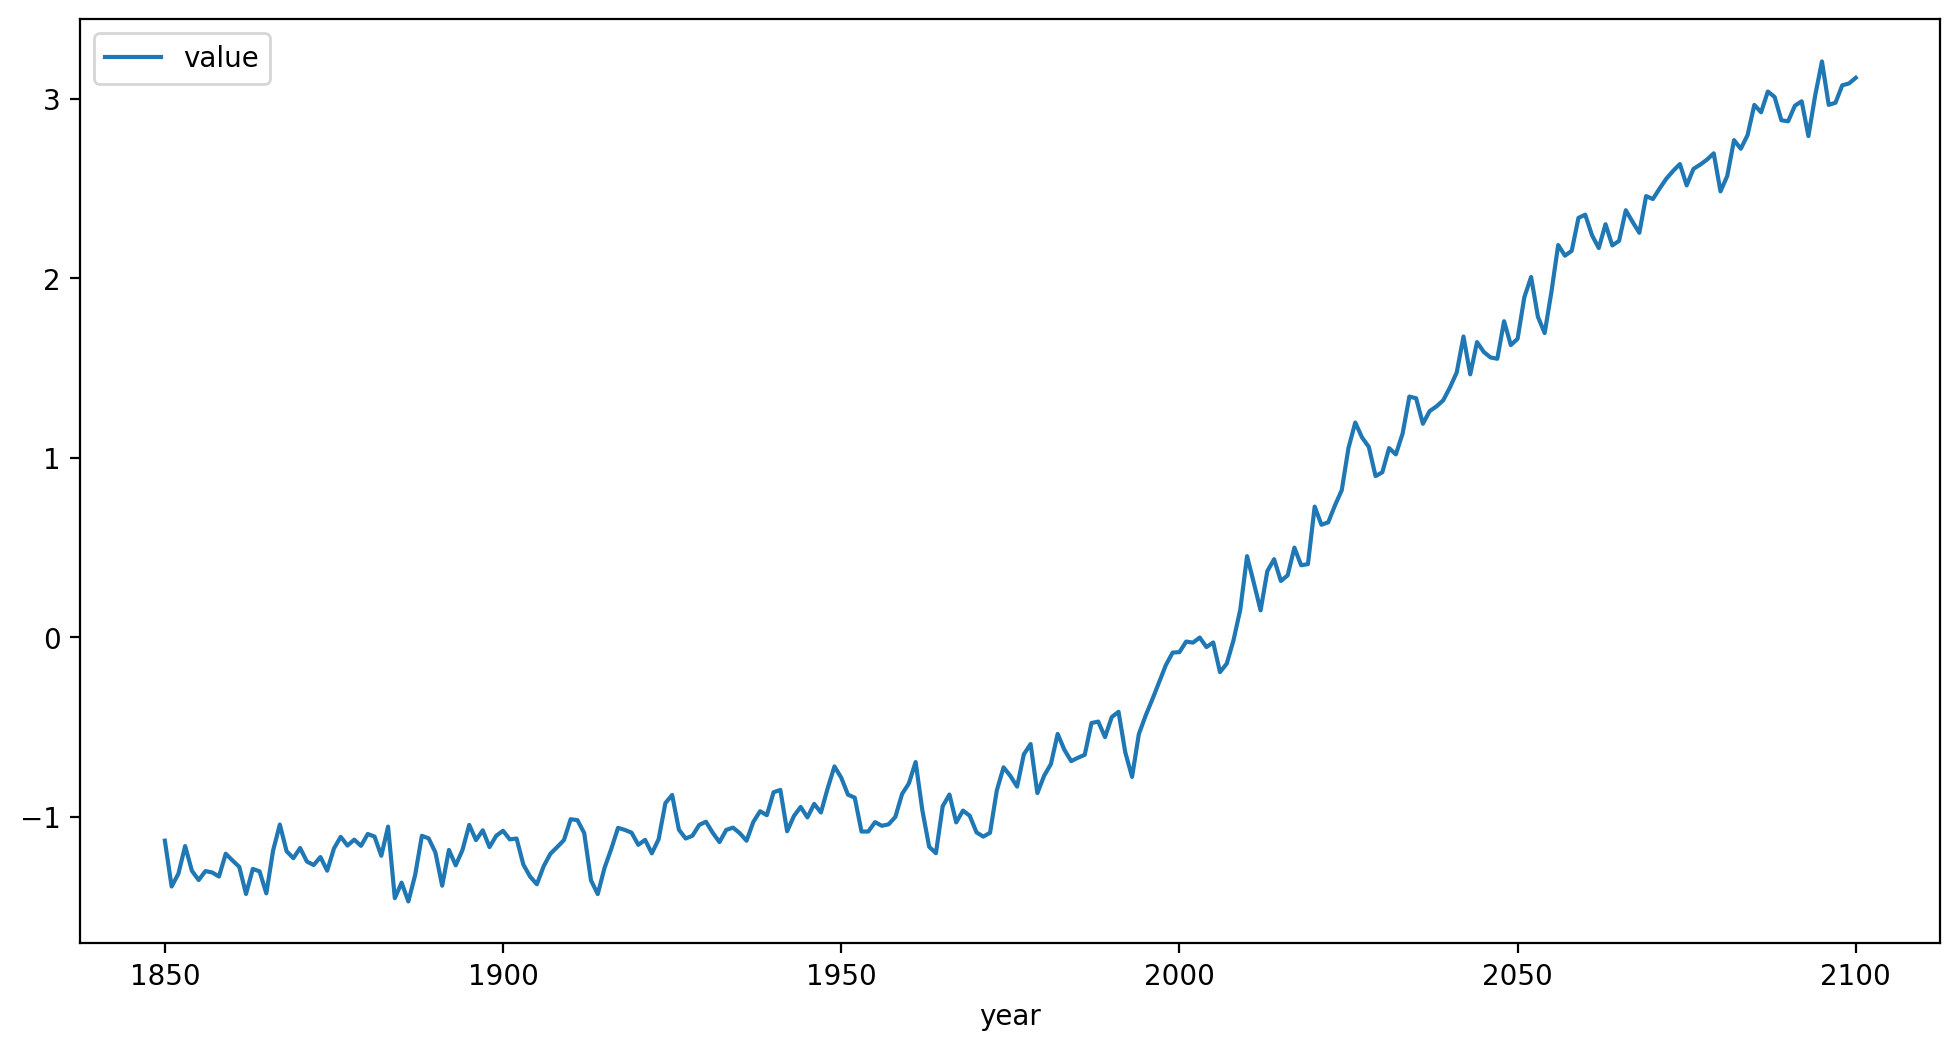

In [5]:
print(target_data.head())
target_data.plot(x="year", y="value")
plt.show()
plt.close()

- Critically, these time series are _global average temperature anomaly from
1995-2014 average_.

- In this demonstration, we will specifically be targeting ensemble member 1
of the CanESM5 SSP245 simulations. The entire SSP245 ensemble may be
jointly targeted by omitting the line
`target_data  = target_data[target_data["ensemble"].isin(['r1i1p1f1'])].copy()`

# Decide on the archive data

- Limit the archive matching data to the model we are trying to emulate, CanESM5
in this case.

- In this example, we treat SSP245 as a novel scenario rather than one
run by the ESM and available, so we exclude it from the archive data.

- `stitches` actually provides two files in its pacakge data.
- `matching_archive.csv` can be considered the default (for now). Starting in
1850, nine year windows are sliced forward and don't overlap.
- The final window ends up beginning in 2093, and is only 8 years long to
terminate in 2100 (7 years if the ESM ends in 2099).

This training will demonstrate the more flexible archive setting options.
- `stitches` includes `matching_archive_staggered.csv` as package
data as well. The difference is that this file does every possible full 9-year chunk,
not just slicing sequentially from the starting point.


In [6]:
# read in the package data of all ESMs-Scenarios-ensemble members avail.
data_directory = pkg_resources.resource_filename("stitches", "data")
path = os.path.join(data_directory, "matching_archive_staggered.csv")
data = pd.read_csv(path)

staggered_archive = data.copy()

end_yr_vector = [
    1858,
    1866,
    1875,
    1884,
    1893,
    1902,
    1911,
    1920,
    1929,
    1938,
    1947,
    1956,
    1965,
    1974,
    1983,
    1992,
    2001,
    2010,
    2019,
    2028,
    2037,
    2046,
    2055,
    2064,
    2073,
    2082,
    2091,
    2100,
]

tmp = staggered_archive.loc[
    (data["experiment"].isin(["ssp126", "ssp370", "ssp585"]))
    & (data["model"] == "CanESM5")
].copy()

archive_data = stitches.fx_processing.subset_archive(
    staggered_archive=tmp, end_yr_vector=end_yr_vector
)

print(archive_data)

        model experiment variable   ensemble  \
0     CanESM5     ssp126      tas  r10i1p1f1   
1     CanESM5     ssp126      tas  r11i1p1f1   
2     CanESM5     ssp126      tas  r12i1p1f1   
3     CanESM5     ssp126      tas  r13i1p1f1   
4     CanESM5     ssp126      tas  r14i1p1f1   
...       ...        ...      ...        ...   
2095  CanESM5     ssp585      tas   r9i1p1f1   
2096  CanESM5     ssp585      tas   r9i1p1f1   
2097  CanESM5     ssp585      tas   r9i1p1f1   
2098  CanESM5     ssp585      tas   r9i1p1f1   
2099  CanESM5     ssp585      tas   r9i1p1f1   

                                     unit  start_yr  end_yr  year        fx  \
0     degC change from avg over 1995~2014      1850    1858  1854 -1.360399   
1     degC change from avg over 1995~2014      1850    1858  1854 -1.235783   
2     degC change from avg over 1995~2014      1850    1858  1854 -1.378939   
3     degC change from avg over 1995~2014      1850    1858  1854 -1.390443   
4     degC change from avg o



# Target data pre-processing
- We had decided to target SSP245 realization 1 to emulate

- The first step of pre-processing any target data is to smooth it.

In [7]:
target_data = stitches.fx_processing.calculate_rolling_mean(target_data, size=31).copy()

For consistency with how we set up the archive, we will have  the target
window ending in 2100 be a complete 9 years and work back.

You can use the `base_chunk=8` argument to do that.
`base_chunk=8` means the target starts in 1850+8 = 1858 and cuts every 9
years after that, ending in 2100.


In [8]:
target_data = stitches.fx_processing.get_chunk_info(
    stitches.fx_processing.chunk_ts(df=target_data, n=9, base_chunk=8)
).copy()
print(target_data)

      model variable experiment  ensemble  \
0   CanESM5      tas     ssp245  r1i1p1f1   
1   CanESM5      tas     ssp245  r1i1p1f1   
2   CanESM5      tas     ssp245  r1i1p1f1   
3   CanESM5      tas     ssp245  r1i1p1f1   
4   CanESM5      tas     ssp245  r1i1p1f1   
5   CanESM5      tas     ssp245  r1i1p1f1   
6   CanESM5      tas     ssp245  r1i1p1f1   
7   CanESM5      tas     ssp245  r1i1p1f1   
8   CanESM5      tas     ssp245  r1i1p1f1   
9   CanESM5      tas     ssp245  r1i1p1f1   
10  CanESM5      tas     ssp245  r1i1p1f1   
11  CanESM5      tas     ssp245  r1i1p1f1   
12  CanESM5      tas     ssp245  r1i1p1f1   
13  CanESM5      tas     ssp245  r1i1p1f1   
14  CanESM5      tas     ssp245  r1i1p1f1   
15  CanESM5      tas     ssp245  r1i1p1f1   
16  CanESM5      tas     ssp245  r1i1p1f1   
17  CanESM5      tas     ssp245  r1i1p1f1   
18  CanESM5      tas     ssp245  r1i1p1f1   
19  CanESM5      tas     ssp245  r1i1p1f1   
20  CanESM5      tas     ssp245  r1i1p1f1   
21  CanESM

# Emulate

This occurs with two functions:
- `stitches.make_recipe()` does the matching between a target and archive,
and gives the pointers to all of the pangeo-hosted netcdf files of data.
- `stitches.gmat_stitching()` or `stitches.gridded_stitching()` then stitch either
global average temperature anomaly  trajectories or gridded, multivariate netcdfs
from those recipes.

# Matching and making the recipe.
The arguments for making recipes are relatively simple. You specify the
target data, the archive data, how many matches you want to try to make for
each realization of the target data, and whether you want your results to be
reproducible.

Two other optional variables include
- `non_tas_variables` - which variables in addition to tas do you think you want to
have gridded results for? The default is to only provide tas recipes.
- `res` - do you want to stitch monthly (`'mon'`) or daily (`'day'`) gridded
results? The default is to monthly as daily files are very large to work with and
create.

The remaining argument, `tol` specifies the matching tolerance - for each target
window, how far out away in the archive are we willing to look for similar points?
- `stitches` prioritizes providing a nearest neighbor match, which dictates how it
currently uses `tol`
- `tol=0.0` corresponds to providing the nearest neighbor match.
- Each target window gets its own, custom nearest neighbor match that is some
distance away, `dist_nn`.
- For each target window, we center a circular matching neighborhood on the
target point. In a radius of `dist_nn`, we know the nearest neighbor is the only
available point by definition.
- Therefore, we expand the matching neighborhood for each target point to
search for matches up to a distance of `dist_nn + tol` away.
- So if target window A has a nearest neighbor 0.1degC away, and `tol=0.01`,
then a circle centered on A with radius 0.11degC contains all possible matches.
If target window B has a nearest neighbor 0.05degC away, then its matching
neighborhood is a circle centered on B with a radius of 0.06degC.


- In the paper, we provide `z_cutoff` values that are 'safe' maximum tolerances
to use for every ESM examined. We will be adding more ESMs in the future.

In [9]:
# the nearest neighbor recipes
nn_recipes = stitches.make_recipe(
    target_data=target_data,
    archive_data=archive_data,
    tol=0.0,
    N_matches=4,
    reproducible=True,
)
print(nn_recipes.head())
print(nn_recipes.tail())

More recipes requested than possible for at least one target trajectories, returning what can
The following target windows have a nearest neighbor in T, dT space
that is more than 0.25degC away. This may or may not result in poor
matches and we recommend validation.
  target_variable target_experiment target_ensemble target_model  \
0             tas            ssp245        r1i1p1f1      CanESM5   

   target_start_yr  target_end_yr  target_year  target_fx  target_dx  \
0             2083           2091         2087   2.832238   0.012831   

  archive_experiment  ... archive_model archive_ensemble archive_start_yr  \
0             ssp370  ...       CanESM5        r17i1p1f1             2056   

   archive_end_yr  archive_year  archive_fx  archive_dx   dist_dx   dist_fx  \
0            2064          2060    2.815717    0.045724  0.263149  0.016521   

    dist_l2  
0  0.263667  

[1 rows x 21 columns]
--------------------------------------------------------------------------------------

More flexible matches

In [10]:
# additional recipes
my_recipes = stitches.make_recipe(
    target_data=target_data,
    archive_data=archive_data,
    tol=0.05,
    res="mon",
    non_tas_variables=["pr"],
    N_matches=4,
    reproducible=True,
)
print(my_recipes.head())
print("-----------------------------------")
# you can take a look at one of the actual file addresses to get a sense of
# what the Pangeo file addresses look like.:
print(my_recipes["pr_file"].iloc[0])

More recipes requested than possible for at least one target trajectories, returning what can
  target_start_yr target_end_yr archive_experiment archive_variable  \
0            1858          1866         historical              tas   
1            1867          1875         historical              tas   
2            1876          1884         historical              tas   
3            1885          1893         historical              tas   
4            1894          1902         historical              tas   

  archive_model archive_ensemble       stitching_id archive_start_yr  \
0       CanESM5        r11i1p1f1  ssp245~r1i1p1f1~1             1894   
1       CanESM5        r22i1p1f1  ssp245~r1i1p1f1~1             1850   
2       CanESM5         r1i1p1f1  ssp245~r1i1p1f1~1             1912   
3       CanESM5         r5i1p1f1  ssp245~r1i1p1f1~1             1850   
4       CanESM5        r19i1p1f1  ssp245~r1i1p1f1~1             1894   

  archive_end_yr                              

If you wanted to include sea level pressure in addition to precipitation, you would use
`non_tas_variables=['pr', 'psl']`.


# stitching and plotting

## Nearest neighbor result
Stitch the global average temperature for the nearest neighbor result,
and see it in the context of the actual ESM data that was not used in the archive
at all.

In [11]:
stitched_global_temp = stitches.gmat_stitching(nn_recipes)

### nearest neighbor stitched realization

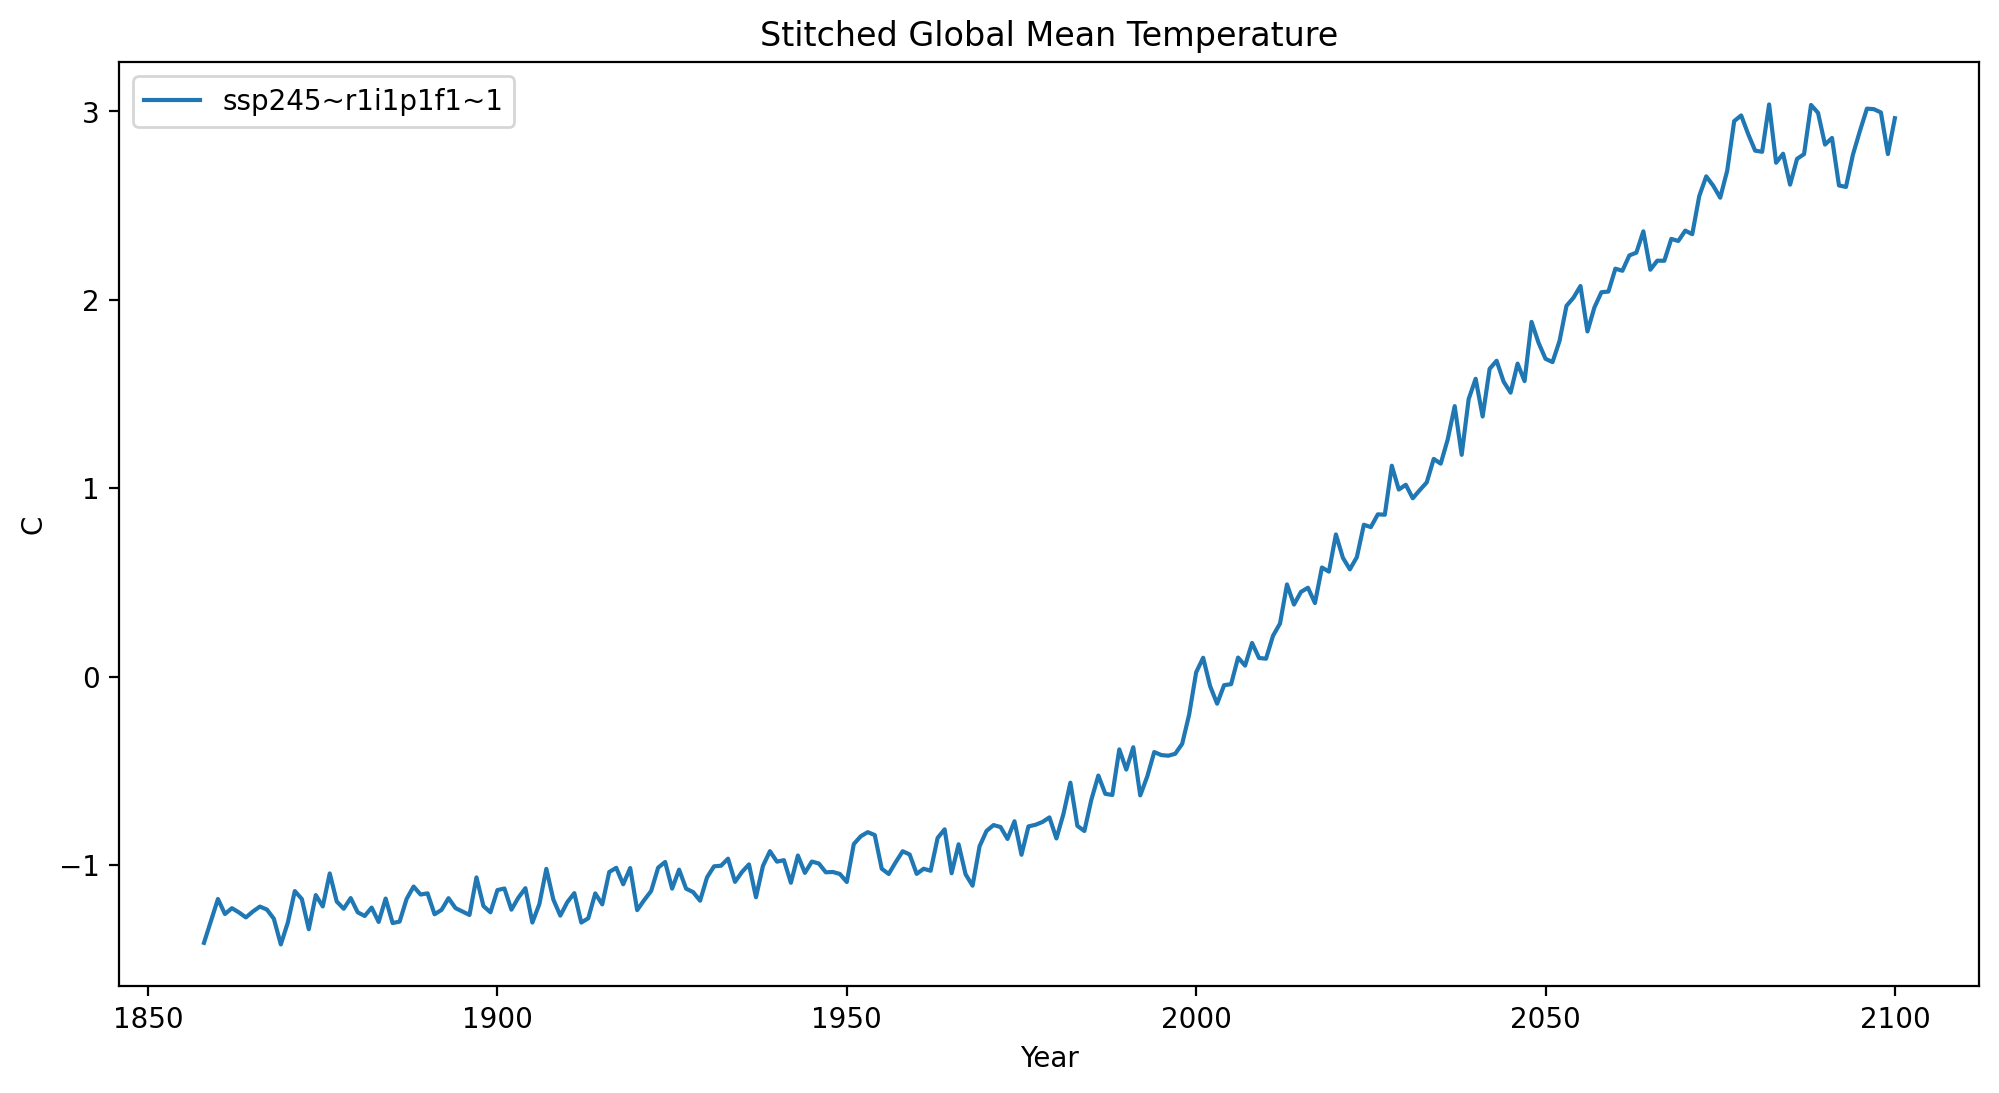

In [12]:
groups = stitched_global_temp.groupby("stitching_id")

for name, group in groups:
    plt.plot(group.year, group.value, label=name)

plt.xlabel("Year")
plt.ylabel("C")
plt.title("Stitched Global Mean Temperature")
plt.legend()
plt.show()
plt.close()


# Load the comparison GSAT data
data_directory = pkg_resources.resource_filename("stitches", "data")
data_path = os.path.join(data_directory, "tas-data", "CanESM5_tas.csv")

comp_data = pd.read_csv(data_path)
comp_data = comp_data.loc[comp_data["experiment"] == "ssp245"]

### stitched realization and the target ensemble member

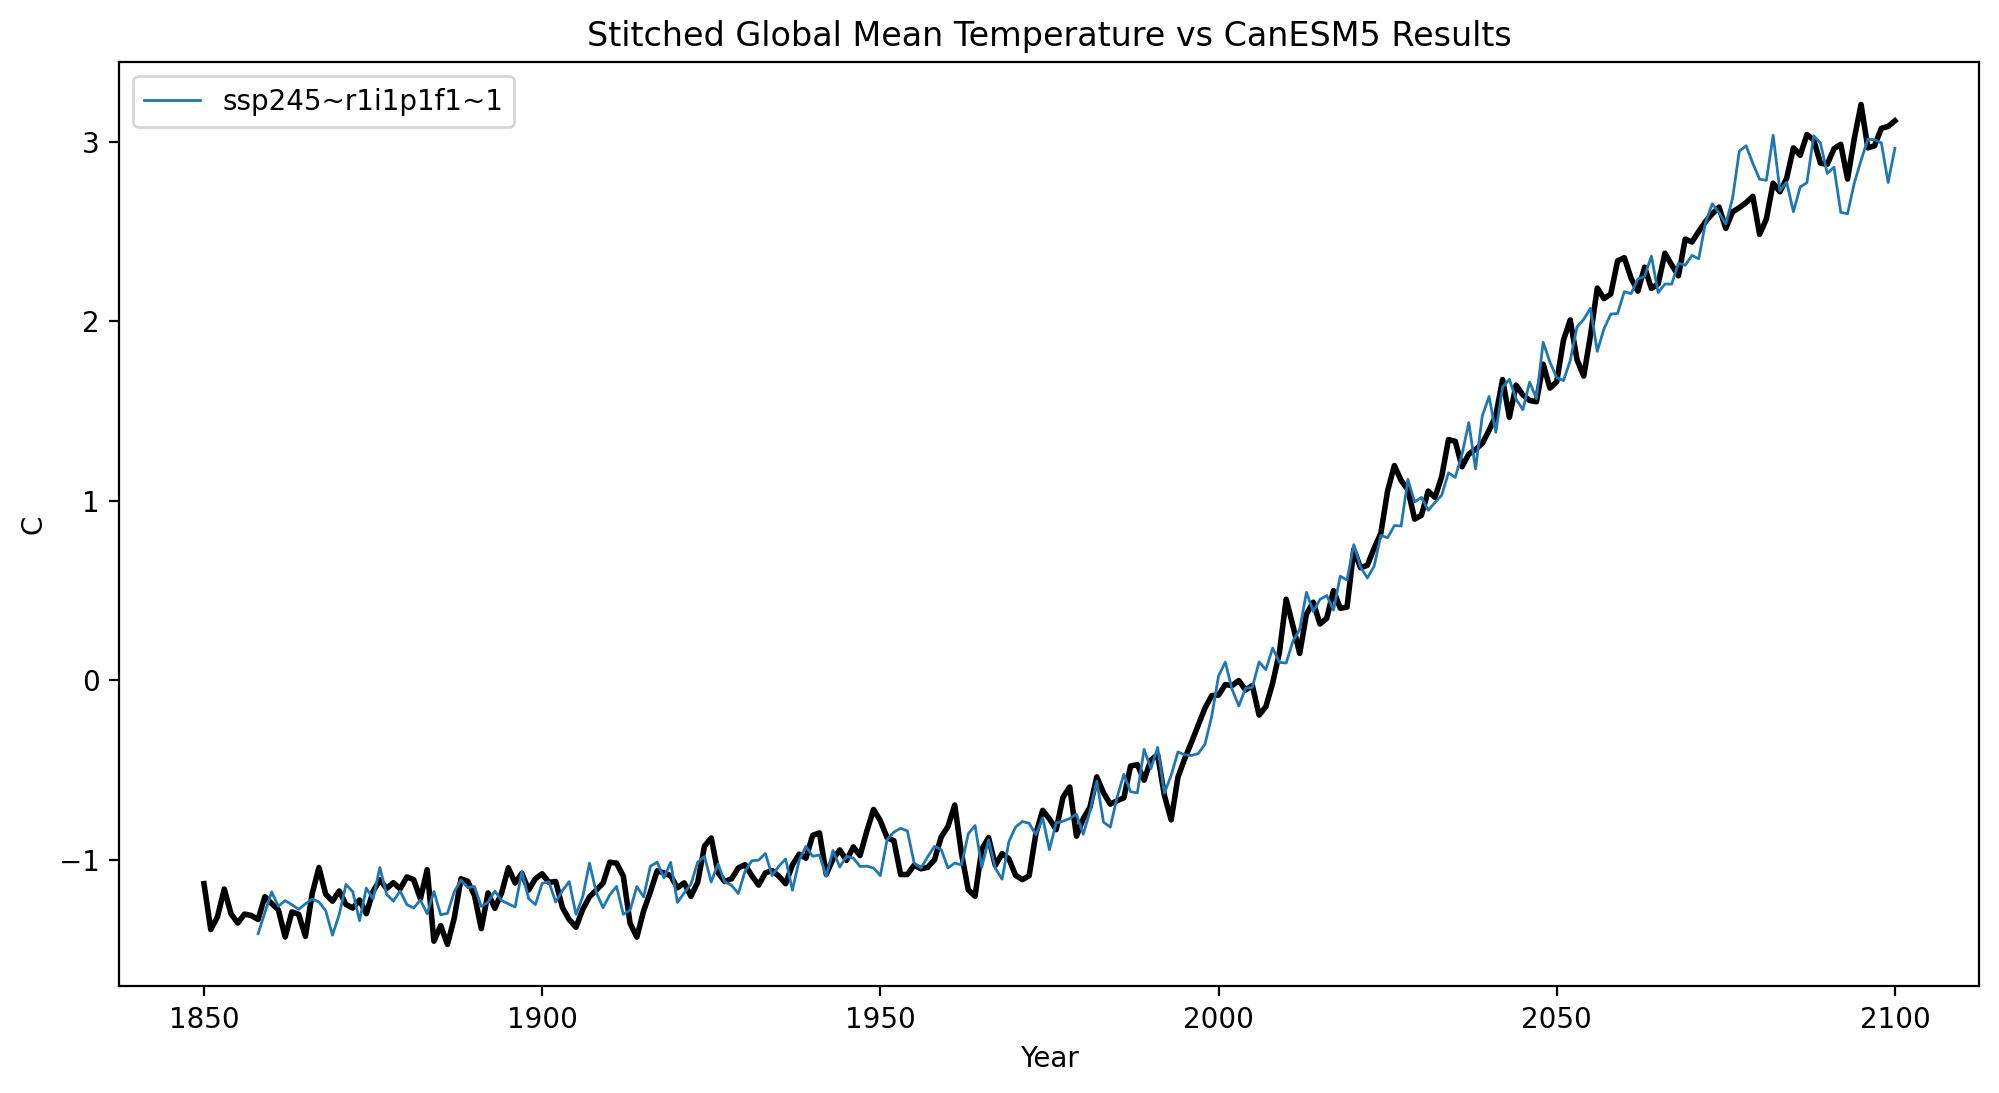

In [13]:
groups = comp_data.groupby("ensemble")
for name, group in groups:
    if group.ensemble.unique() == "r1i1p1f1":
        plt.plot(group.year, group.value, color="black", linewidth=2.0)
# The stitched realizations:
groups = stitched_global_temp.groupby("stitching_id")
for name, group in groups:
    plt.plot(group.year, group.value, linewidth=1.0, label=name)

plt.legend()
plt.xlabel("Year")
plt.ylabel("C")
plt.title("Stitched Global Mean Temperature vs CanESM5 Results")
plt.show()
plt.close()

### stitched realization and the entire scenario ensemble

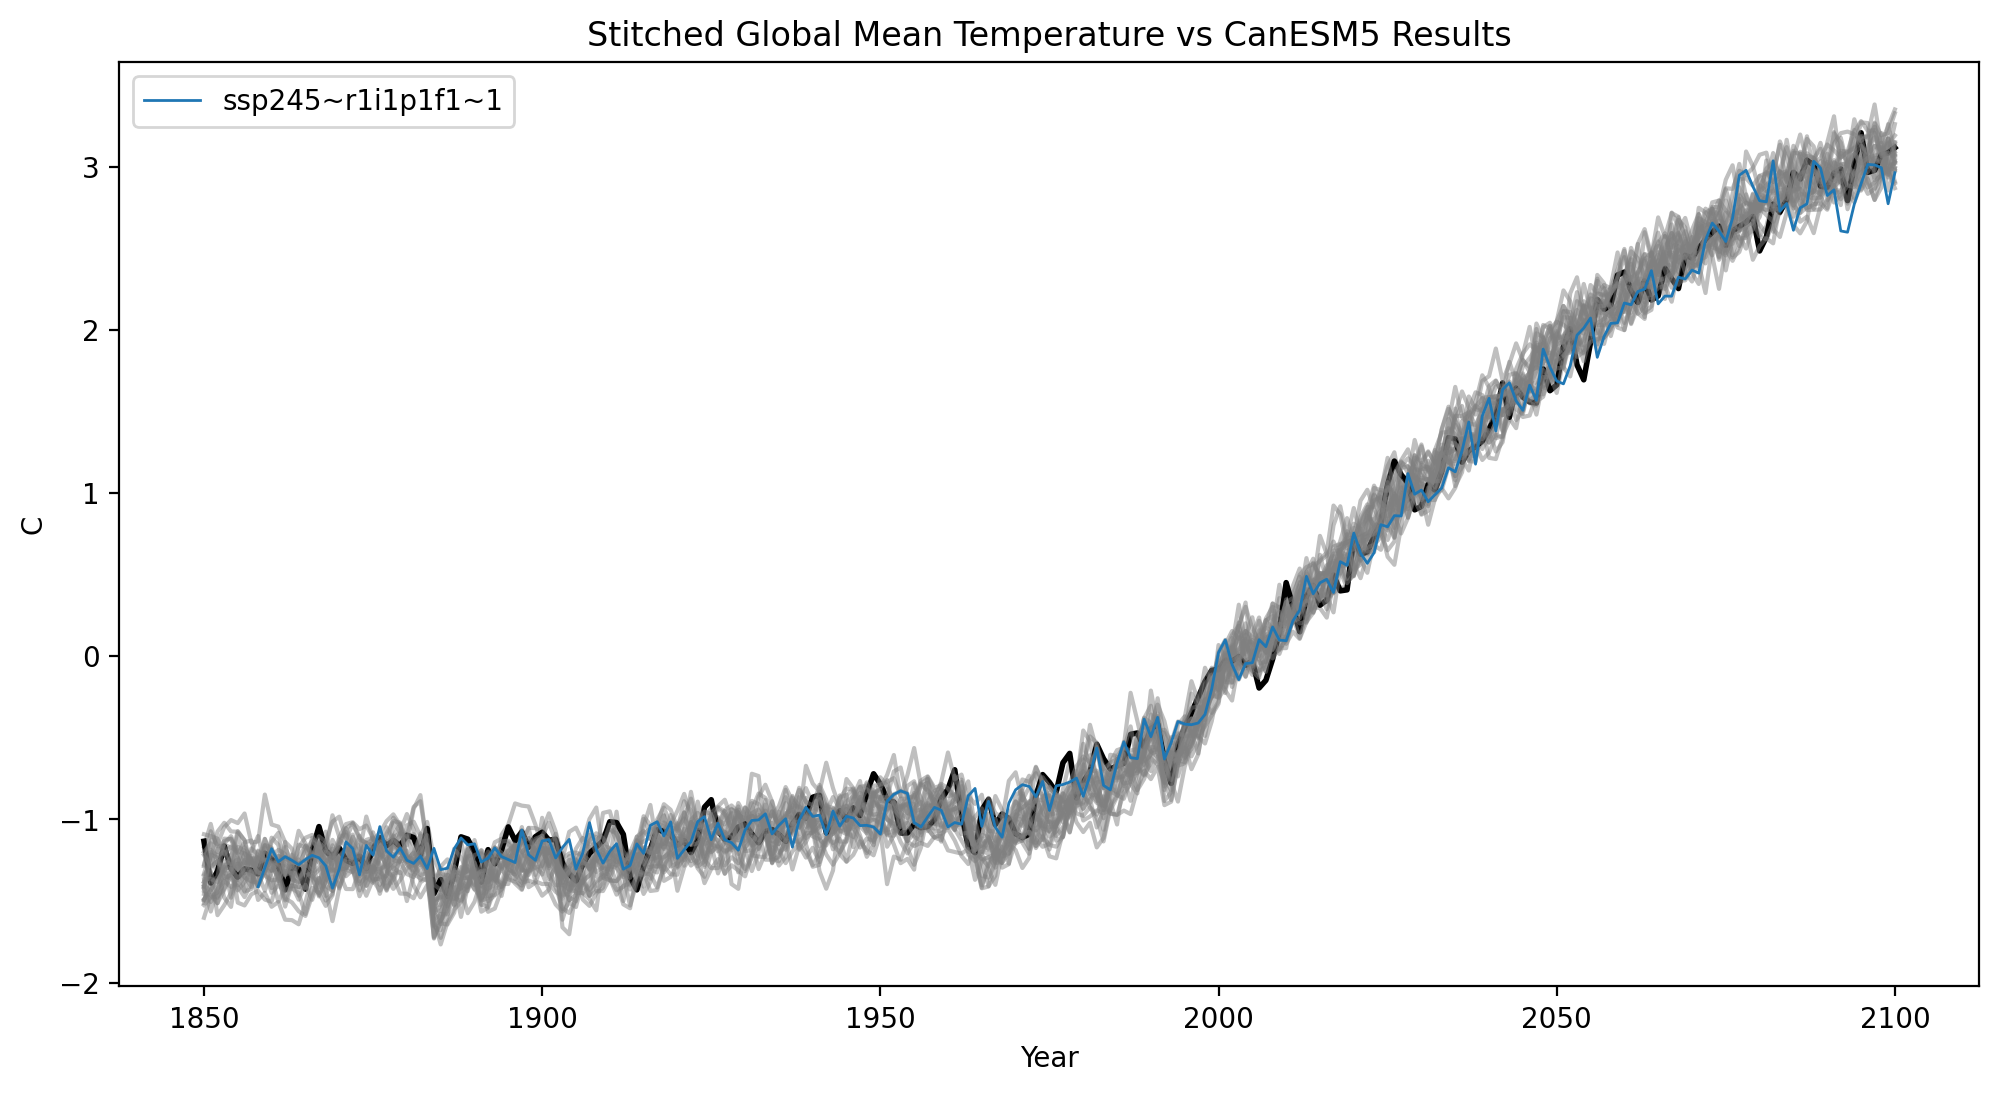

In [14]:
# full ensemble of actual ESM runs:
groups = comp_data.groupby("ensemble")
for name, group in groups:
    if group.ensemble.unique() == "r1i1p1f1":
        plt.plot(group.year, group.value, color="black", linewidth=2.0)
    else:
        plt.plot(group.year, group.value, color="0.5", alpha=0.5)

# The stitched realizations:
groups = stitched_global_temp.groupby("stitching_id")
for name, group in groups:
    plt.plot(group.year, group.value, linewidth=1.0, label=name)

plt.legend()
plt.xlabel("Year")
plt.ylabel("C")
plt.title("Stitched Global Mean Temperature vs CanESM5 Results")
plt.show()
plt.close()

# gridded stitching of the non-NN recipes

This is a little slow, but it will create the netcdfs according to our stitched recipes
that we can load in and work with.

In [16]:
stitches.gridded_stitching(out_dir=".", rp=my_recipes)

Validating request availability with Pangeo archive contents...
Fetching: gs://cmip6/CMIP6/CMIP/CCCma/CanESM5/historical/r10i1p1f1/Amon/pr/gn/v20190429/


Fetching: gs://cmip6/CMIP6/CMIP/CCCma/CanESM5/historical/r10i1p1f1/Amon/tas/gn/v20190429/


Fetching: gs://cmip6/CMIP6/CMIP/CCCma/CanESM5/historical/r11i1p1f1/Amon/pr/gn/v20190429/


Fetching: gs://cmip6/CMIP6/CMIP/CCCma/CanESM5/historical/r11i1p1f1/Amon/tas/gn/v20190429/


Fetching: gs://cmip6/CMIP6/CMIP/CCCma/CanESM5/historical/r12i1p1f1/Amon/pr/gn/v20190429/


...

Fetching: gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp585/r4i1p1f1/Amon/pr/gn/v20190429/


Fetching: gs://cmip6/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp585/r4i1p1f1/Amon/tas/gn/v20190429/


Compiled downloads into 84 datasets.
Stitching gridded netcdf for: ['CanESM5'] ['tas'] ssp245~r1i1p1f1~1 ...


/opt/conda/lib/python3.11/site-packages/stitches/fx_stitch.py:100: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range(
/opt/conda/lib/python3.11/site-packages/stitches/fx_stitch.py:100: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range(
/opt/conda/lib/python3.11/site-packages/stitches/fx_stitch.py:100: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range(
/opt/conda/lib/python3.11/site-packages/stitches/fx_stitch.py:100: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range(
/opt/conda/lib/python3.11/site-packages/stitches/fx_stitch.py:100: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range(
/opt/conda/lib/python3.11/site-packages/stitches/fx_stitch.py:100: FutureWarning: 'M'

PermissionError: [Errno 13] Permission denied: '/home/jovyan/notebooks/stitched_CanESM5_tas_ssp245~r1i1p1f1~1.nc'

now you have created multiple gridded, monthly tas and pr files that are
statistically consistent with the target: SSP245 realization 1.

In [ ]:
import xarray as xr

gen_tas = xr.open_dataset("stitched_CanESM5_tas_ssp245~r1i1p1f1~1.nc")
gen_tas

In [ ]:
gen_pr = xr.open_dataset("stitched_CanESM5_pr_ssp245~r1i1p1f1~1.nc")
gen_pr

# Pull comparison netcdfs

In [ ]:
# Fetch the actual data directly from pangeo
data_directory = pkg_resources.resource_filename("stitches", "data")
pangeo_path = os.path.join(data_directory, "pangeo_table.csv")

pangeo_data = pd.read_csv(pangeo_path)

pangeo_data = pangeo_data.loc[
    (pangeo_data["variable"].isin(["tas", "pr"]))
    & (pangeo_data["domain"].str.contains("mon"))
    & (pangeo_data["experiment"].isin(["ssp245"]))
    & (pangeo_data["ensemble"].isin(["r1i1p1f1"]))
    & (pangeo_data["model"].isin(["CanESM5"]))
].copy()

# load the target tas netcdf files
tas_address = pangeo_data.loc[pangeo_data["variable"] == "tas"].zstore.copy()
tar_tas = stitches.fetch_nc(tas_address.values[0])

# load the target pr netcdf files
pr_address = pangeo_data.loc[pangeo_data["variable"] == "pr"].zstore.copy()
tar_pr = stitches.fetch_nc(pr_address.values[0])

# Visualize

Select a grid cell and plot the generated and target tas, pr data for first-cut comparison

In [ ]:
# define a helper function


def plot_comparison(generated_data, target_data, variable, alpha=0.8):
    """Plot comparision between target variable time series and generated data"""

    if variable.casefold() == "pr":
        variable_name = "precipitation"
        units = "kg m-2 s-1"
    else:
        variable_name = "temperature"
        units = "C"

    # temperature (tas)
    plt.plot(
        generated_data.time,
        generated_data[variable],
        label=f"Generated monthly {variable}",
    )

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")

        plt.plot(
            target_data.indexes["time"].to_datetimeindex(),
            target_data[variable],
            alpha=alpha,
            label=f"Target monthly {variable}",
        )

    plt.legend()
    plt.xlabel("Year")
    plt.ylabel(units)
    plt.title(f"Actual and generated monthly {variable_name} ({variable})")
    plt.show()
    plt.close()


# lon and lat values for a grid cell near the Joint Global Change Research Institute in College Park, MD, USA
cp_lat = 38.9897
cp_lon = 180 + 76.9378

# lat and lon coordinates closest
abslat = np.abs(gen_tas.lat - cp_lat)
abslon = np.abs(gen_tas.lon - cp_lon)
c = np.maximum(abslon, abslat)
([lon_loc], [lat_loc]) = np.where(c == np.min(c))
lon_grid = gen_tas.lon[lon_loc]
lat_grid = gen_tas.lat[lat_loc]

cp_tas_gen = gen_tas.sel(
    lon=lon_grid, lat=lat_grid, time=slice("2015-01-01", "2099-12-31")
).copy()

cp_tas_tar = tar_tas.sel(
    lon=lon_grid, lat=lat_grid, time=slice("2015-01-01", "2099-12-31")
).copy()

cp_pr_gen = gen_pr.sel(
    lon=lon_grid, lat=lat_grid, time=slice("2015-01-01", "2099-12-31")
).copy()

cp_pr_tar = tar_pr.sel(
    lon=lon_grid, lat=lat_grid, time=slice("2015-01-01", "2099-12-31")
).copy()

# temperature (tas)
plot_comparison(generated_data=cp_tas_gen, target_data=cp_tas_tar, variable="tas")

# precipitation (pr)
plot_comparison(generated_data=cp_pr_gen, target_data=cp_pr_tar, variable="pr")

Visual validation of the complex spatial, temporal, and cross-variable
relationships present in ESM outputs is not possible. We extensively validate
that the method reproduces ESM internal variability in the ESD paper, but this
visual plotting at least suggests that nothing is obviously wrong. In particular,
there are no obvious artifacts occurring every 9-years in the generated time
series.


In other words, it's not inconceivable from these plots that the orange time
series were sampled from the same underlying multivariate distribution that
generated the blue time series.